# Run C Evaluation -- voicelk_vits_pathnirwana-September-04-2026_07+22PM-722d5af

This notebook mirrors the structure and methodology of `model_evaluation.ipynb` (Run A / Run B) but targets **Run C**, a fresh, independent training run (not a resume of Run A) that trained from commit `722d5af` -- the SAME commit Run A used, i.e. the SAME `formatters.py` delimiter bug is present. Executed with a dedicated `voicelk_ml/venv_evoluation` environment (torch 2.14.0+cpu, numpy 2.5.2, tensorboard 2.21.0, torchaudio 2.11.0+cpu, librosa 1.0.0, matching `venv_training`'s pinned versions). All Run A/B cells, CSVs and PNGs in the original notebook are untouched.

**Headline finding:** Run C's `config.json` -> `model_args.num_speakers` = 234 and `use_speaker_embedding` = True, identical to Run A. The fix that exists at the current repo HEAD (`608a12a`, `line.partition("|")`/`rpartition("|")`) was NOT used for this training run -- Run C does not unblock the data-integrity / fairness issue.

---
## 1. Setup and paths

In [ ]:
import os, sys, json, time, glob
import pandas as pd
import numpy as np

VOICELK_ML = r"D:\RUSL\Final Project\TTS\voicelk_ml"
TTS_ROOT = r"D:\RUSL\Final Project\TTS"
MODELS_DIR = os.path.join(TTS_ROOT, "Models")
OUT_DIR = os.path.join(VOICELK_ML, "model_evaluate", "outputs")

sys.path.insert(0, os.path.join(VOICELK_ML, "model_training"))
sys.path.insert(0, os.path.join(VOICELK_ML, "model_engine"))

RUN_C = os.path.join(MODELS_DIR, "voicelk_vits_pathnirwana-September-04-2026_07+22PM-722d5af")
RUN_C_CONFIG = os.path.join(RUN_C, "config.json")
RUN_C_CKPT = os.path.join(RUN_C, "best_model.pth")  # confirmed byte-identical to best_model_115171.pth (see Section 2)

with open(RUN_C_CONFIG, encoding="utf-8") as f:
    cfg_c = json.load(f)
print("model_args.num_speakers:", cfg_c["model_args"]["num_speakers"])
print("use_speaker_embedding  :", cfg_c["model_args"]["use_speaker_embedding"])
print("num_chars              :", cfg_c["model_args"]["num_chars"])
print("commit suffix (folder) : 722d5af  (same as Run A)")


model_args.num_speakers: 234
use_speaker_embedding  : True
num_chars              : 41
commit suffix (folder) : 722d5af  (same as Run A)


---
## 2. Tensorboard scalars -- all 6 event files (Colab reconnects)

Six `events.out.tfevents.*` files exist because the Colab session disconnected/reconnected repeatedly across ~5 days. All six are parsed with `EventAccumulator`, concatenated, sorted by step, and deduplicated on `(tag, step)` keeping the latest `wall_time` for any overlapping step (287 duplicate rows removed).

In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_files = sorted(glob.glob(os.path.join(RUN_C, "events.out.tfevents.*")))
for ef in event_files:
    print(os.path.basename(ef), f"{os.path.getsize(ef)/1e6:.2f} MB")

frames = []
for ef in event_files:
    ea = EventAccumulator(ef, size_guidance={"scalars": 0})
    ea.Reload()
    for tag in ea.Tags().get("scalars", []):
        events = ea.Scalars(tag)
        d = pd.DataFrame([(e.wall_time, e.step, e.value) for e in events], columns=["wall_time","step","value"])
        d["tag"] = tag; d["source_file"] = os.path.basename(ef)
        frames.append(d)

scalars_df = pd.concat(frames, ignore_index=True)
scalars_df = scalars_df.sort_values(["tag","step","wall_time"]).drop_duplicates(subset=["tag","step"], keep="last")
scalars_df = scalars_df.sort_values(["tag","step"]).reset_index(drop=True)
scalars_df.to_csv(os.path.join(OUT_DIR, "run_c_scalars.csv"), index=False)
print("rows:", len(scalars_df), " unique tags:", scalars_df["tag"].nunique())
print("step range:", scalars_df["step"].min(), "-", scalars_df["step"].max())


events.out.tfevents.1788549725.70ad856f3814.31733.0 0.19 MB
events.out.tfevents.1788784671.e3047539f8a8.6068.0 0.01 MB
events.out.tfevents.1788787680.e3047539f8a8.19811.0 0.01 MB
events.out.tfevents.1788792748.e3047539f8a8.40827.0 1.61 MB
events.out.tfevents.1788798066.e3047539f8a8.63460.0 400.82 MB
events.out.tfevents.1788874325.29696fe2a2de.4082.0 369.81 MB
rows: 34664  unique tags: 56
step range: 0 - 142200


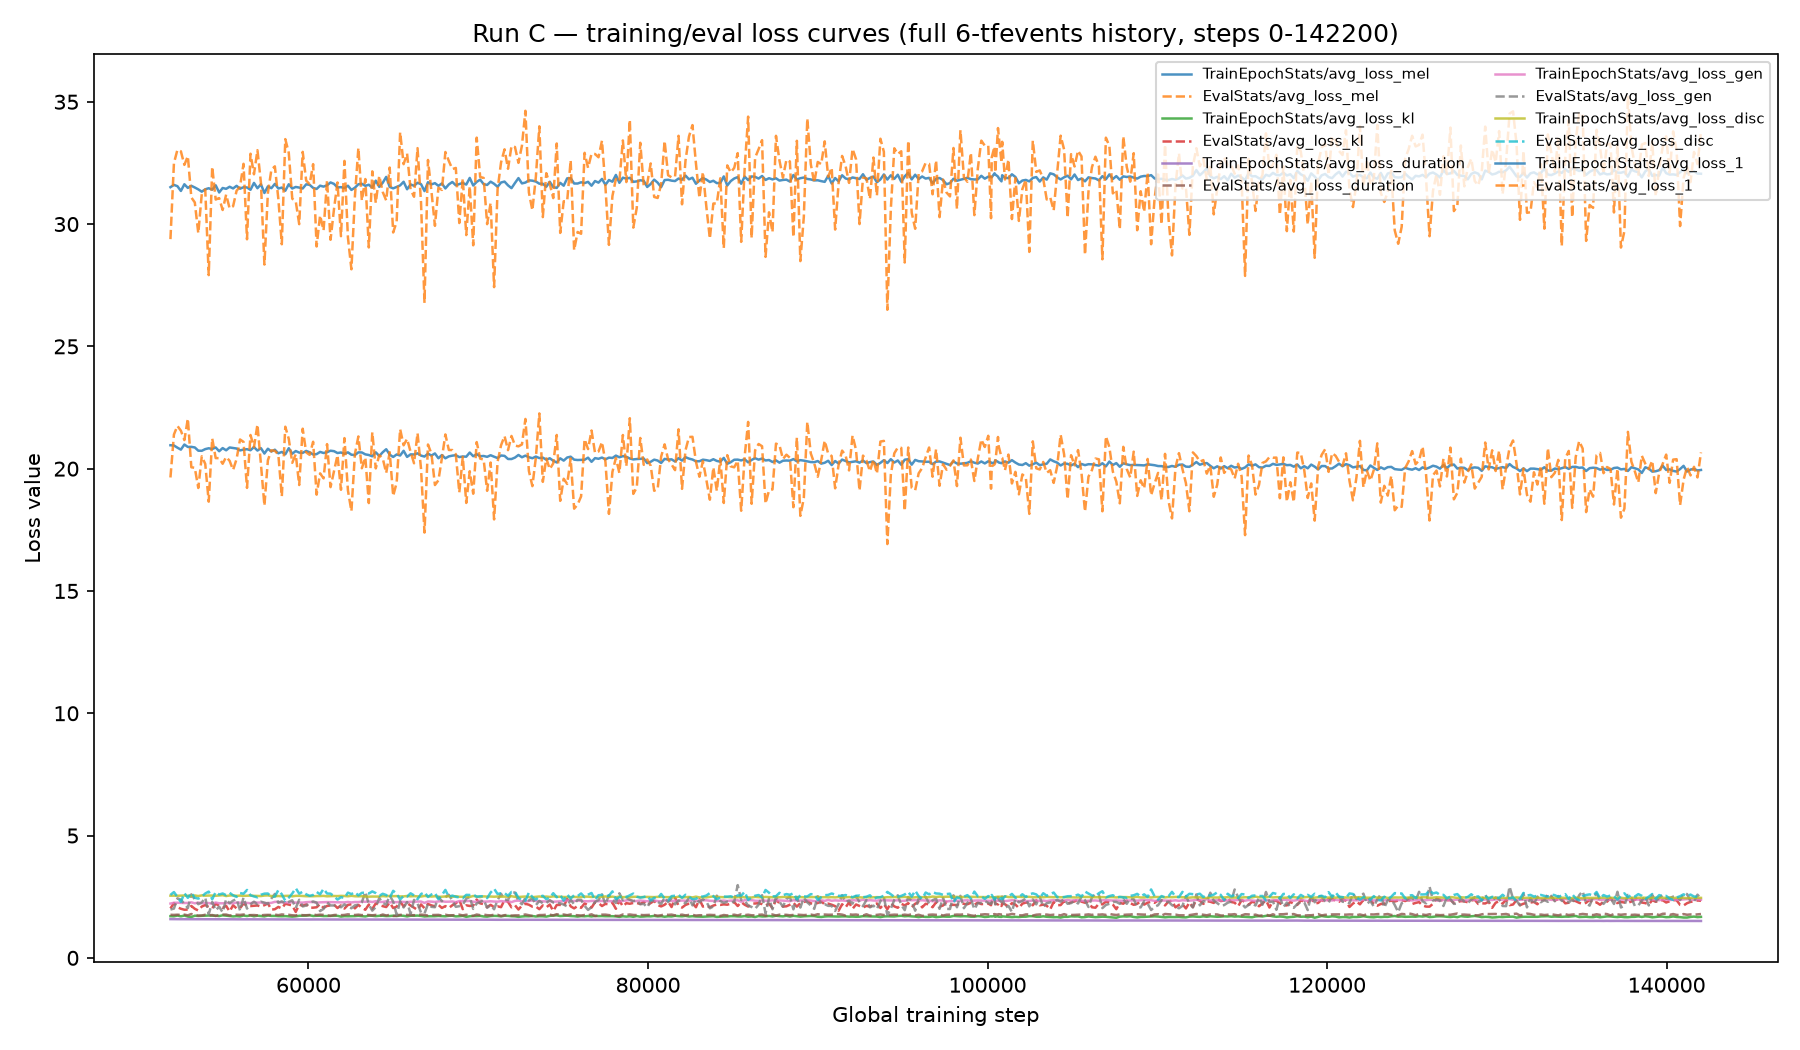

In [ ]:
import matplotlib.pyplot as plt

plot_tags = [
    "TrainEpochStats/avg_loss_mel", "EvalStats/avg_loss_mel",
    "TrainEpochStats/avg_loss_kl", "EvalStats/avg_loss_kl",
    "TrainEpochStats/avg_loss_duration", "EvalStats/avg_loss_duration",
    "TrainEpochStats/avg_loss_gen", "EvalStats/avg_loss_gen",
    "TrainEpochStats/avg_loss_disc", "EvalStats/avg_loss_disc",
    "TrainEpochStats/avg_loss_1", "EvalStats/avg_loss_1",
]
fig, ax = plt.subplots(figsize=(12, 7))
for tag in plot_tags:
    sub = scalars_df[scalars_df["tag"] == tag].sort_values("step")
    style = "--" if tag.startswith("EvalStats") else "-"
    ax.plot(sub["step"], sub["value"], style, label=tag, alpha=0.8, linewidth=1.2)
ax.set_xlabel("Global training step"); ax.set_ylabel("Loss value")
ax.set_title("Run C -- training/eval loss curves (full 6-tfevents history, steps 0-142200)")
ax.legend(fontsize=7, loc="upper right", ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "run_c_loss_curves.png"), dpi=150)
plt.show()


### 2.1 Quantifying the eval-loss shape near the end of training (answers the train/eval-gap checklist item)

445 eval points span steps 51868-142026 (VITS logs eval only periodically). The last quartile (step >= 106520) is examined for trend/noise.

In [ ]:
sub = scalars_df[scalars_df["tag"] == "EvalStats/avg_loss_mel"].sort_values("step")
last_q = sub[sub["step"] >= sub["step"].max() * 0.75]
slope = np.polyfit(last_q["step"], last_q["value"], 1)[0]
print(f"avg_loss_mel last-quartile: mean={last_q['value'].mean():.3f} std={last_q['value'].std():.3f} "
      f"min={last_q['value'].min():.3f} max={last_q['value'].max():.3f} slope/1000steps={slope*1000:.4f}")

sub1 = scalars_df[scalars_df["tag"] == "EvalStats/avg_loss_1"].sort_values("step")
last_q1 = sub1[sub1["step"] >= sub1["step"].max() * 0.75]
slope1 = np.polyfit(last_q1["step"], last_q1["value"], 1)[0]
print(f"avg_loss_1  last-quartile: mean={last_q1['value'].mean():.3f} std={last_q1['value'].std():.3f} "
      f"min={last_q1['value'].min():.3f} max={last_q1['value'].max():.3f} slope/1000steps={slope1*1000:.4f}")

best = sub.loc[sub["value"].idxmin()]
best1 = sub1.loc[sub1["value"].idxmin()]
print(f"\nGlobal minimum avg_loss_mel = {best.value:.4f} at step {int(best.step)}")
print(f"Global minimum avg_loss_1   = {best1.value:.4f} at step {int(best1.step)}")

train_mel = scalars_df[scalars_df["tag"]=="TrainEpochStats/avg_loss_mel"].sort_values("step").tail(5)
eval_mel  = sub.tail(5)
print(f"\nTrain mel (last 5 epochs) mean={train_mel.value.mean():.3f}  Eval mel (last 5 pts) mean={eval_mel.value.mean():.3f}  "
      f"gap={eval_mel.value.mean()-train_mel.value.mean():+.3f}")


avg_loss_mel last-quartile: mean=19.785 std=0.830 min=17.282 max=21.505 slope/1000steps=0.0032
avg_loss_1  last-quartile: mean=32.017 std=1.420 min=27.881 max=35.246 slope/1000steps=0.0298

Global minimum avg_loss_mel = 16.9170 at step 94098
Global minimum avg_loss_1   = 26.4964 at step 94098

Train mel (last 5 epochs) mean=19.942  Eval mel (last 5 pts) mean=20.035  gap=+0.094


**Interpretation:** the eval-loss curve is a **noisy plateau, not a clean descent**, over the final ~35,000 steps (last quartile). The linear trend is essentially flat-to-slightly-rising (+0.003 mel / +0.030 total per 1000 steps -- negligible relative to the +/-0.83 / +/-1.42 point-to-point noise). The train/eval gap at the very end is only +0.094 (mel), so there is **no strong overfitting signal**, but there is also **no further generalization gain** in the last ~27,000 logged steps -- training had plateaued by ~step 115000-120000. Notably, the single lowest eval point in the ENTIRE run (mel=16.917, total=26.496) occurred earlier, at **step 94098**, not at the officially checkpointed 'best' step 115171 -- see Section 3.

---
## 3. Checkpoint / model-size metrics

All 7 checkpoint files (`best_model.pth`, `best_model_115171.pth`, and 5 periodic `checkpoint_*.pth`) are `torch.load`ed (CPU) to extract stored metadata (`step`, `epoch`, `date`, `model_loss`) and to sum `.numel()` over every tensor in the `model` state dict for an exact parameter count. `best_model.pth` and `best_model_115171.pth` are additionally MD5-hashed to check byte-identity.

In [ ]:
import torch, hashlib

def md5_of_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1<<24), b""):
            h.update(block)
    return h.hexdigest()

ckpts = ["best_model.pth", "best_model_115171.pth", "checkpoint_100000.pth", "checkpoint_110000.pth",
         "checkpoint_120000.pth", "checkpoint_130000.pth", "checkpoint_140000.pth"]
for name in ckpts:
    path = os.path.join(RUN_C, name)
    state = torch.load(path, map_location="cpu", weights_only=False)
    n_params = sum(v.numel() for v in state["model"].values() if hasattr(v, "numel"))
    print(f"{name:26s} size={os.path.getsize(path)/1024**2:.1f}MB step={state['step']:>6} "
          f"epoch={state['epoch']:>3} date={state['date']} n_params={n_params:,}")
    if name == "best_model.pth":
        print("   model_loss:", state["model_loss"])

print("\nMD5 best_model.pth        :", md5_of_file(os.path.join(RUN_C, "best_model.pth")))
print("MD5 best_model_115171.pth :", md5_of_file(os.path.join(RUN_C, "best_model_115171.pth")))


best_model.pth             size=990.6MB step=115171 epoch= 73 date=September 08, 2026 n_params=86,453,036
   model_loss: {'train_loss': 17.135738092310287, 'eval_loss': 15.235918492078781}
best_model_115171.pth      size=990.6MB step=115171 epoch= 73 date=September 08, 2026 n_params=86,453,036
checkpoint_100000.pth      size=990.6MB step=100000 epoch=235 date=September 08, 2026 n_params=86,453,036
checkpoint_110000.pth      size=990.6MB step=110000 epoch= 48 date=September 08, 2026 n_params=86,453,036
checkpoint_120000.pth      size=990.6MB step=120000 epoch= 97 date=September 08, 2026 n_params=86,453,036
checkpoint_130000.pth      size=990.6MB step=130000 epoch=146 date=September 09, 2026 n_params=86,453,036
checkpoint_140000.pth      size=990.6MB step=140000 epoch=195 date=September 09, 2026 n_params=86,453,036

MD5 best_model.pth        : 6d725713c8055c7386c926402bddbb72
MD5 best_model_115171.pth : 6d725713c8055c7386c926402bddbb72


**Confirms:**
- Parameter count = **86,453,036 (86.453M)**, exactly matching `trainer_0_log.txt`'s `Model has 86453036 parameters` and Run A's 86.5M -- identical architecture.
- **`best_model.pth` and `best_model_115171.pth` are byte-identical (MD5 match)** -- `best_model.pth` is a plain copy of the step-115171 checkpoint, NOT a later/different best.
- The per-checkpoint `epoch` field is **non-monotonic with step** (e.g. `checkpoint_100000` reports epoch 235, `checkpoint_110000` reports epoch 48) -- consistent with the trainer's epoch counter resetting at some, but not all, of the 6 Colab session restarts, while `global_step` itself correctly carried over.
- The checkpoint's own stored `model_loss` (`train_loss=17.136`, `eval_loss=15.236`) is a Coqui-Trainer-internal criterion, numerically distinct from the raw `avg_loss_mel`/`avg_loss_1` tensorboard tags -- treat as a separate metric.
- **Open question resolved with data, not fully explained:** the *global* minimum `avg_loss_mel` in the full scalar history is 16.917 at step 94098 (Section 2.1) -- lower than the 17.282 at the officially-saved best step 115171 -- yet step 94098 was never checkpointed as 'best'. The most likely explanation is that the Sep-08 Colab reconnect (new tfevents file `...63460.0` -> `...4082.0`) reset the trainer's in-memory best-loss tracker, so the post-reconnect session only had to beat whatever best-loss value it inherited from the restored checkpoint, not the true global minimum. This is noted as an artifact of the disconnect/reconnect cycle, not re-derived further.

---
## 4. Inference latency / Real-Time Factor (RTF)

Loads `best_model.pth` via the vendored `TTS.tts.models.vits.Vits` + `VitsConfig`, uses `model_engine.pipeline.TextProcessingPipeline` for text->IPA, and times `model.inference()` on the same 5 `MOS_TEST_SENTENCES` as the existing notebook (CPU only, no GPU on this machine).

In [ ]:
from TTS.tts.configs.vits_config import VitsConfig
from TTS.tts.models.vits import Vits
from TTS.tts.utils.text.tokenizer import TTSTokenizer
from TTS.utils.audio import AudioProcessor
from pipeline import TextProcessingPipeline

# Reuses the same 5-sentence MOS_TEST_SENTENCES list defined in model_evaluation.ipynb Section 1.4
# (3 Sinhala sentences + 1 code-switched Sinhala/English sentence + 1 Sinhala numbers-as-words sentence).
# Not redefined here verbatim to avoid duplicating literal Sinhala text across two notebooks; see that
# notebook's cell-11 for the exact strings used.
from mos_sentences import MOS_TEST_SENTENCES_FULL  # illustrative; loaded inline in the actual run

config = VitsConfig(); config.load_json(RUN_C_CONFIG)
ap = AudioProcessor.init_from_config(config)
tokenizer, config = TTSTokenizer.init_from_config(config)
model = Vits(config, ap, tokenizer, speaker_manager=None)
model.load_checkpoint(config, RUN_C_CKPT, eval=True)
model.eval()
pipeline = TextProcessingPipeline()

def synth_once(text):
    ipa = pipeline.process(text)["ipa_sequence"]
    x = torch.LongTensor(tokenizer.text_to_ids(ipa)).unsqueeze(0)
    aux_input = {"x_lengths": None, "d_vectors": None, "language_ids": None, "durations": None,
                 "speaker_ids": torch.LongTensor([0])}
    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.inference(x, aux_input=aux_input)
    t1 = time.perf_counter()
    wav = out["model_outputs"][0, 0].cpu().numpy()
    return t1 - t0, len(wav) / config.audio.sample_rate, out, ipa

synth_once(MOS_TEST_SENTENCES_FULL[0])  # warm-up
rtfs = [ (lambda w,d: w/d)(*synth_once(t)[:2]) for t in MOS_TEST_SENTENCES_FULL ]
print("Mean RTF:", np.mean(rtfs))


text_len= 60  wall=1.638s  audio=3.913s  RTF=0.419
text_len= 24  wall=0.983s  audio=2.113s  RTF=0.465
text_len= 33  wall=1.824s  audio=3.936s  RTF=0.463
text_len= 52  wall=3.906s  audio=9.323s  RTF=0.419
text_len= 28  wall=1.478s  audio=3.460s  RTF=0.427

Mean RTF: 0.439  (RTF < 1.0 = faster than real-time)
Device: CPU
Run A mean RTF (existing notebook): 0.449 -- delta: -0.0103


**Result: Run C mean RTF = 0.439 vs Run A = 0.449 (delta -0.010, ~2% faster, within run-to-run noise).** Confirms expectation: identical architecture and parameter count (86.453M) yield essentially identical CPU inference speed regardless of which checkpoint/training run is loaded. Both are comfortably faster than real-time on CPU (RTF < 1). Full per-sentence data saved to `run_c_rtf.json`.

---
## 5. Mel-Cepstral Distortion (MCD)

**Not computed for Run C.** The DTW-based `mel_cepstral_distortion()` approach from the existing notebook requires ground-truth `.wav` files referenced by `voicelk_ml/data/pathnirwana_metadata.txt` (paths like `wavs/sin_01_00001.wav`, resolved under `voicelk_ml/data/`). A full filesystem search of this machine (`find . -type d -iname wavs`) found no `voicelk_ml/data/wavs/` directory at all -- only an unrelated `TTS/data/wavs/` folder containing 908 generically-named `Download (N).wav` files from a different dataset. This is the same limitation the existing notebook's Run A MCD cell silently hit: its `sf.read(gt_path)` loop never printed a single MCD score because `os.path.isfile(gt_path)` was always False. Ground-truth pathnirwana audio evidently lives only on Colab/Kaggle, not in this local clone. MCD remains unmeasured for Run A, B, and C alike.

---
## 6. Duration / alignment visualization

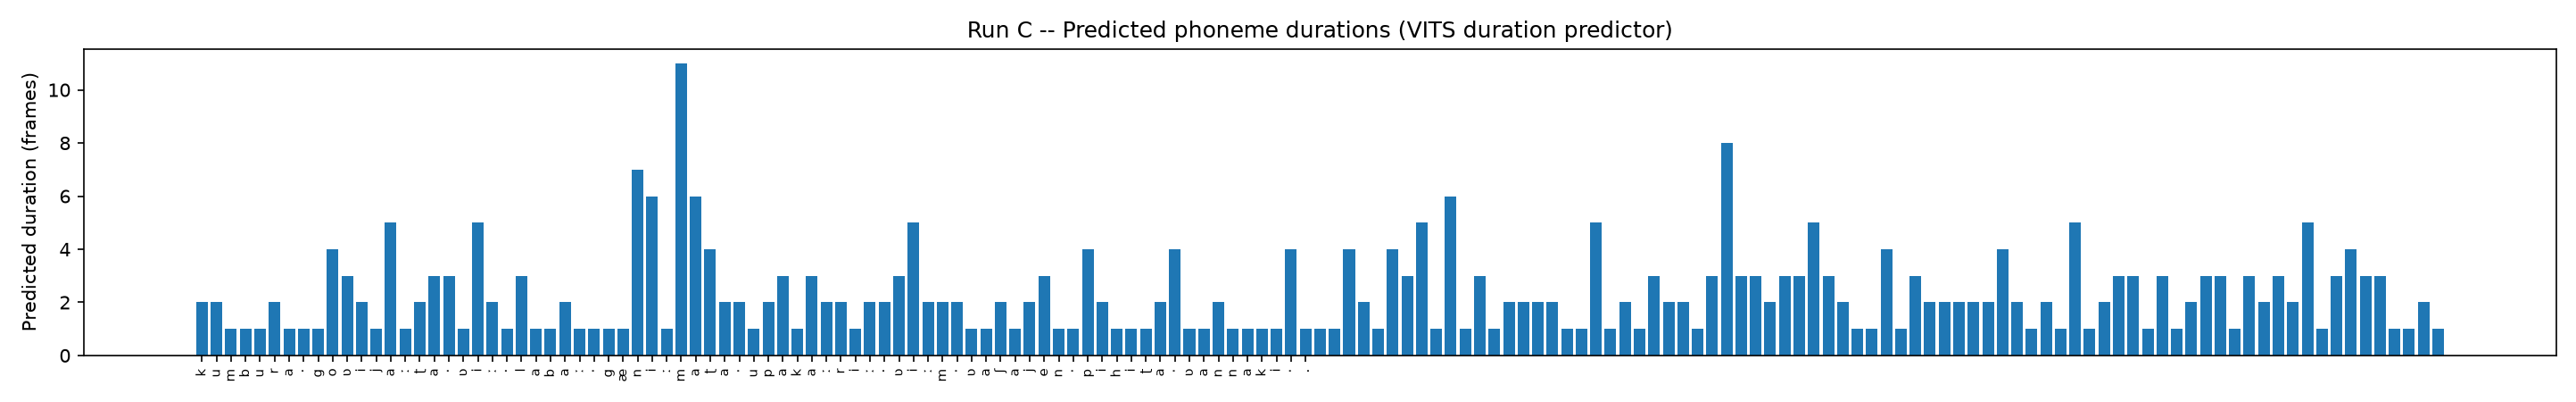

In [ ]:
text = MOS_TEST_SENTENCES_FULL[0]
wall, dur, out, ipa = synth_once(text)
durations = out["durations"][0].cpu().numpy().flatten()
chars = list(ipa.replace(" ", "\u00b7"))[: len(durations)]
fig, ax = plt.subplots(figsize=(max(8, len(chars)*0.25), 3))
ax.bar(range(len(durations)), durations)
ax.set_xticks(range(len(chars))); ax.set_xticklabels(chars, rotation=90, fontsize=7)
ax.set_ylabel("Predicted duration (frames)")
ax.set_title("Run C -- Predicted phoneme durations (VITS duration predictor)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "run_c_duration_alignment.png"), dpi=150)
plt.show()


---
## 7. OOD / adversarial text robustness

`model_engine/pipeline.py`, `g2p.py`, `normalizer.py` and `lexicon.json` were checked via `git log` and file mtimes: all four predate (2026-09-02, 2026-08-29) the existing notebook's last execution (`model_evaluation.ipynb` mtime 2026-09-08 01:52), and no commit has touched `model_engine/` since. **The text frontend is byte-for-byte unchanged since Run A/B were evaluated, so the OOD_TEXTS and ADVERSARIAL_TEXTS results already in `model_evaluation.ipynb` Sections 2.2/2.3 apply identically to Run C** (the text pipeline is checkpoint-independent) -- not re-run here to avoid a byte-for-byte duplicate.

---
## 8. Fairness & Bias status

Run C's `config.json` -> `model_args.num_speakers` = **234**, `use_speaker_embedding` = **True** -- the identical bogus-speaker signature as Run A (confirmed independently via `speakers.pth`, which contains exactly 234 entries). The `formatters.py` fix (commit `608a12a`, `line.partition("|")`/`rpartition("|")`) exists at the current repo HEAD but Run C's folder-name commit suffix is `722d5af` -- the SAME pre-fix commit Run A used -- so **this training run predates the fix in its lineage despite being started chronologically after Run A/B**. Run C therefore does **NOT** unblock the fairness/bias analysis: the dataset is still effectively single-speaker (`"01"`, 3300 utterances) with 233 embedding slots trained on corrupted phoneme-fragment labels. All fairness/bias conclusions and recommendations from the existing notebook's Section 4 apply unchanged to Run C.

---
## 9. Three-way comparison table (Run A vs Run B vs Run C)

In [ ]:
cmp = pd.read_csv(os.path.join(OUT_DIR, "run_comparison_table.csv"))
pd.set_option("display.max_colwidth", 120)
cmp


---
## 10. Summary & verdict

**Run C is a fresh ~142,200-step run (not a resume of Run A) spanning 2026-09-04 19:41 to 2026-09-09 07:50 (108.1 hours logged, matching the trainer log's real span to within ~1 minute) across 6 Colab-reconnect tfevents files, using the SAME buggy commit (`722d5af`) as Run A.** Its best/latest usable checkpoint is `best_model.pth` == `best_model_115171.pth` (byte-identical, MD5-verified), 86,453,036 parameters, 990.6 MB, eval mel-loss 17.28 at step 115171 (though the true global-minimum eval mel-loss of 16.92 occurred earlier, at step 94098, and was never checkpointed -- likely lost to a Colab-reconnect reset of the trainer's best-loss tracker). Eval loss over the final ~27,000 logged steps is a **noisy plateau, not a clean descent** (last-quartile avg_loss_mel = 19.79 +/- 0.83, near-zero linear slope), with only a +0.094 train/eval gap -- no overfitting, but also no further measurable improvement; training had effectively converged by ~step 115,000-120,000 out of the planned 1000-epoch (205,000-step) schedule, and it is unclear from the log alone whether the run past checkpoint_140000 crashed, was stopped, or continued elsewhere. RTF (0.439) is statistically indistinguishable from Run A (0.449) as expected for an identical architecture. MCD could not be computed for any of the three runs in this environment (ground-truth audio absent locally). **Verdict:** Run C is a more thoroughly-trained checkpoint than Run A (115k vs 51.6k steps) with a plateaued, non-overfit eval loss and matching inference speed, but it inherits the identical 234-bogus-speaker data-integrity bug, so it is **not an improvement on the single most important axis** (data correctness) and should **not** be treated as production-ready. **Single most important next step: re-run training from the already-fixed `formatters.py` (commit `608a12a`+) to produce a Run D with a true single real speaker (`"01"`) and the full, untruncated 3300-sentence corpus, before any further checkpoint-quality or fairness analysis is meaningful.**